# Week 15: CodeGnosis + Retrieval Integration

## The Full Hypothesis

**"The model can predict its own errors using internal signals, AND retrieval at those moments improves accuracy."**

## What We've Proven So Far

| Week | Finding |
|------|--------|
| Week 13 | CCE alone does NOT predict errors well (r=0.065) |
| Week 14 V1 | Hidden states CAN be extracted during generation |
| Week 14 V2 | **All Features (CCE + Hidden + Attention) achieves 83.6% accuracy** |

## This Experiment

1. Train CodeGnosis classifier on code generation data
2. During generation, predict error probability using CodeGnosis
3. When error probability > threshold: trigger retrieval
4. Compare conditions:
   - **A: No retrieval** (baseline)
   - **B: CodeGnosis-triggered retrieval** (our approach)
   - **C: Always retrieve** (upper bound)
   - **D: Random retrieval** (control)

In [1]:
!pip install -q torch transformers accelerate bitsandbytes sentence-transformers scipy numpy pandas matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 43.5 MB/s eta 0:00:00


In [2]:
import os
import ast
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import random
import subprocess
import tempfile
import sys
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [3]:
# Clone httpx for retrieval corpus
REPO_URL = 'https://github.com/encode/httpx.git'
REPO_DIR = '/content/httpx'

if not os.path.exists(REPO_DIR):
    !git clone --depth 1 {REPO_URL} {REPO_DIR}

def load_source_files(repo_dir: str, src_folder: str = 'httpx') -> Dict[str, str]:
    files = {}
    src_path = os.path.join(repo_dir, src_folder)
    for root, _, filenames in os.walk(src_path):
        for fname in filenames:
            if fname.endswith('.py'):
                fpath = os.path.join(root, fname)
                rel_path = os.path.relpath(fpath, repo_dir)
                with open(fpath, 'r', encoding='utf-8') as f:
                    files[rel_path] = f.read()
    return files

SOURCE_FILES = load_source_files(REPO_DIR)
print(f"Loaded {len(SOURCE_FILES)} source files")

Cloning into '/content/httpx'...
remote: Enumerating objects: 140, done.
remote: Counting objects: 100% (140/140), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 140 (delta 2), reused 50 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (140/140), 2.21 MiB | 15.10 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Loaded 23 source files


In [4]:
# Load models
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    output_hidden_states=True,
    output_attentions=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Embedding model for retrieval
embedder = SentenceTransformer('all-MiniLM-L6-v2')

print(f"Models loaded! Hidden dim: {model.config.hidden_size}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/646 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Models loaded! Hidden dim: 4096


## Build Retrieval Index

In [5]:
def chunk_source_files(source_files: Dict[str, str], chunk_size: int = 40) -> List[Dict]:
    """Split source files into chunks for retrieval."""
    chunks = []
    for filepath, content in source_files.items():
        lines = content.split('\n')
        for i in range(0, len(lines), chunk_size // 2):
            chunk_lines = lines[i:i + chunk_size]
            if len(chunk_lines) < 5:
                continue
            chunk_text = '\n'.join(chunk_lines)
            chunks.append({
                'filepath': filepath,
                'start_line': i + 1,
                'content': chunk_text,
            })
    return chunks

SOURCE_CHUNKS = chunk_source_files(SOURCE_FILES)
print(f"Created {len(SOURCE_CHUNKS)} chunks")

# Embed chunks
print("Embedding chunks...")
chunk_texts = [c['content'] for c in SOURCE_CHUNKS]
CHUNK_EMBEDDINGS = embedder.encode(chunk_texts, show_progress_bar=True, convert_to_tensor=True)
print(f"Embeddings shape: {CHUNK_EMBEDDINGS.shape}")

Created 448 chunks
Embedding chunks...


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Embeddings shape: torch.Size([448, 384])


In [6]:
def retrieve_context(query: str, top_k: int = 3, max_chars: int = 1500) -> str:
    """Retrieve relevant source code for a query."""
    query_embedding = embedder.encode(query, convert_to_tensor=True)
    similarities = F.cosine_similarity(query_embedding.unsqueeze(0), CHUNK_EMBEDDINGS)
    top_indices = torch.topk(similarities, k=min(top_k, len(SOURCE_CHUNKS))).indices

    context_parts = []
    total_chars = 0
    for idx in top_indices:
        chunk = SOURCE_CHUNKS[idx.item()]
        chunk_text = f"# From {chunk['filepath']}:\n{chunk['content']}"
        if total_chars + len(chunk_text) > max_chars:
            break
        context_parts.append(chunk_text)
        total_chars += len(chunk_text)

    return "\n\n".join(context_parts)

# Test
test_ctx = retrieve_context("httpx timeout configuration")
print(f"Test retrieval ({len(test_ctx)} chars):")
print(test_ctx[:300] + "...")

Test retrieval (1417 chars):
# From httpx/_client.py:

        return request.stream

    def _set_timeout(self, request: Request) -> None:
        if "timeout" not in request.extensions:
            timeout = (
                self.timeout
                if isinstance(self.timeout, UseClientDefault)
                else Timeo...


## CodeGnosis: Train Error Predictor

Use the best approach from Week 14 V2: All Features + Logistic Regression

In [7]:
# Training tasks (separate from evaluation tasks)
TRAINING_TASKS = [
    # Easy (correct)
    {'prompt': 'Write a function to add two numbers'},
    {'prompt': 'Write a function to subtract two numbers'},
    {'prompt': 'Write a function to check if number is even'},
    {'prompt': 'Write a function to find max of two numbers'},
    {'prompt': 'Write a function to reverse a string'},
    {'prompt': 'Write a function to check if string is empty'},
    {'prompt': 'Write a function to get list length'},
    {'prompt': 'Write a function to append to list'},
    {'prompt': 'Write a function to check if key in dict'},
    {'prompt': 'Write a function to get dict value with default'},

    # Medium
    {'prompt': 'Write a function to find second largest in list'},
    {'prompt': 'Write a function to remove duplicates from list'},
    {'prompt': 'Write a function to count word frequency'},
    {'prompt': 'Write a function to check if palindrome'},
    {'prompt': 'Write a function to find factorial recursively'},

    # Hard (likely errors)
    {'prompt': 'Write a function to implement quicksort'},
    {'prompt': 'Write a function for longest common subsequence'},
    {'prompt': 'Write a function to detect cycle in linked list'},
    {'prompt': 'Write a function to balance parentheses'},
    {'prompt': 'Write a function for matrix multiplication'},

    # API tasks (likely errors)
    {'prompt': 'Write code using httpx to GET with custom headers'},
    {'prompt': 'Write code using httpx to POST JSON data'},
    {'prompt': 'Write code using httpx Client with timeout'},
    {'prompt': 'Write code using httpx to handle HTTP errors'},
    {'prompt': 'Write code using httpx AsyncClient'},
    {'prompt': 'Write code using httpx to stream response'},
    {'prompt': 'Write code using httpx BasicAuth'},
    {'prompt': 'Write code using httpx to follow redirects'},

    # Async (often errors)
    {'prompt': 'Write async function with asyncio.gather'},
    {'prompt': 'Write async function with asyncio.wait_for'},
    {'prompt': 'Write async producer-consumer with Queue'},

    # Stdlib
    {'prompt': 'Write code using functools.lru_cache'},
    {'prompt': 'Write code using itertools.groupby'},
    {'prompt': 'Write code using collections.Counter'},
    {'prompt': 'Write code using contextlib.contextmanager'},
]

print(f"Training tasks: {len(TRAINING_TASKS)}")

Training tasks: 35


In [8]:
def extract_features_from_generation(hidden_states, output_entropy, attention_entropy, num_tokens, code):
    """Extract features for CodeGnosis classifier."""
    hs_stack = torch.stack(hidden_states) if hidden_states else torch.zeros(1, 4096)
    output_ent = np.array(output_entropy) if output_entropy else np.array([0.0])
    attn_ent = np.array(attention_entropy) if attention_entropy else np.array([0.0])

    features = {
        'hs_mean_norm': float(hs_stack.mean(dim=0).norm()),
        'hs_max_norm': float(hs_stack.max(dim=0).values.norm()),
        'hs_std_mean': float(hs_stack.std(dim=0).mean()),
        'hs_last_norm': float(hs_stack[-1].norm()),
        'cce_mean': float(output_ent.mean()),
        'cce_max': float(output_ent.max()),
        'cce_std': float(output_ent.std()) if len(output_ent) > 1 else 0.0,
        'cce_median': float(np.median(output_ent)),
        'cce_q75': float(np.percentile(output_ent, 75)),
        'cce_q90': float(np.percentile(output_ent, 90)),
        'cce_spikes_2': float((output_ent > 2.0).sum()),
        'cce_spikes_3': float((output_ent > 3.0).sum()),
        'attn_mean': float(attn_ent.mean()),
        'attn_max': float(attn_ent.max()),
        'attn_std': float(attn_ent.std()) if len(attn_ent) > 1 else 0.0,
        'num_tokens': float(num_tokens),
        'tokens_per_line': float(num_tokens / max(1, code.count('\n') + 1)),
    }
    return features

FEATURE_NAMES = list(extract_features_from_generation([], [0.1], [0.1], 10, "test").keys())
print(f"Features: {FEATURE_NAMES}")

Features: ['hs_mean_norm', 'hs_max_norm', 'hs_std_mean', 'hs_last_norm', 'cce_mean', 'cce_max', 'cce_std', 'cce_median', 'cce_q75', 'cce_q90', 'cce_spikes_2', 'cce_spikes_3', 'attn_mean', 'attn_max', 'attn_std', 'num_tokens', 'tokens_per_line']


/tmp/ipython-input-4249452355.py:10: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  'hs_std_mean': float(hs_stack.std(dim=0).mean()),


In [9]:
def generate_with_internals(model, tokenizer, prompt: str, max_tokens: int = 150):
    """Generate code and extract internal states."""
    full_prompt = f"[INST] {prompt}\n\nWrite only Python code. [/INST]\n\n```python\n"
    input_ids = tokenizer.encode(full_prompt, return_tensors='pt').to(model.device)

    hidden_states_list, attention_entropy_list, output_entropy_list, generated_tokens = [], [], [], []

    with torch.no_grad():
        for _ in range(max_tokens):
            outputs = model(input_ids, output_hidden_states=True, output_attentions=True)
            logits = outputs.logits[:, -1, :].float()

            # CCE
            probs = F.softmax(logits, dim=-1)
            output_entropy = -(probs * torch.log2(probs + 1e-10)).sum(dim=-1).item()
            output_entropy_list.append(output_entropy)

            # Hidden state
            hidden_states_list.append(outputs.hidden_states[-1][:, -1, :].squeeze(0).cpu())

            # Attention entropy
            last_layer_attn = outputs.attentions[-1]
            avg_attn = last_layer_attn[0, :, -1, :].mean(dim=0)
            attn_entropy = -(avg_attn * torch.log2(avg_attn + 1e-10)).sum().item()
            attention_entropy_list.append(attn_entropy)

            # Next token
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
            generated_tokens.append(next_token.item())
            input_ids = torch.cat([input_ids, next_token], dim=-1)

            if next_token.item() == tokenizer.eos_token_id:
                break
            decoded = tokenizer.decode(generated_tokens[-10:] if len(generated_tokens) >= 10 else generated_tokens)
            if '```' in decoded and len(generated_tokens) > 20:
                break

    code = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    code = code.replace('```python', '').replace('```', '').strip()

    return code, hidden_states_list, output_entropy_list, attention_entropy_list, generated_tokens

In [10]:
def verify_code(code: str) -> bool:
    """Check if code executes without error."""
    try:
        ast.parse(code)
    except SyntaxError:
        return False

    try:
        with tempfile.NamedTemporaryFile(mode='w', suffix='.py', delete=False) as f:
            f.write(code)
            temp_path = f.name
        result = subprocess.run([sys.executable, temp_path], capture_output=True, timeout=5)
        os.unlink(temp_path)
        return result.returncode == 0
    except:
        return False

In [11]:
%%time

# Generate training data for CodeGnosis
print("Generating training data for CodeGnosis...")
training_data = []

for i, task in enumerate(TRAINING_TASKS):
    print(f"[{i+1}/{len(TRAINING_TASKS)}] {task['prompt'][:40]}...", end=" ")

    code, hs, oe, ae, tokens = generate_with_internals(model, tokenizer, task['prompt'])
    is_correct = verify_code(code)

    features = extract_features_from_generation(hs, oe, ae, len(tokens), code)
    training_data.append({
        'features': features,
        'is_correct': is_correct,
        'prompt': task['prompt'],
    })

    print("OK" if is_correct else "ERR")

print(f"\nTraining data: {len(training_data)}")
print(f"Correct: {sum(1 for d in training_data if d['is_correct'])}")
print(f"Errors: {sum(1 for d in training_data if not d['is_correct'])}")

Generating training data for CodeGnosis...
[1/35] Write a function to add two numbers... ERR
[2/35] Write a function to subtract two numbers... ERR
[3/35] Write a function to check if number is e... OK
[4/35] Write a function to find max of two numb... OK
[5/35] Write a function to reverse a string... ERR
[6/35] Write a function to check if string is e... OK
[7/35] Write a function to get list length... OK
[8/35] Write a function to append to list... OK
[9/35] Write a function to check if key in dict... OK
[10/35] Write a function to get dict value with ... OK
[11/35] Write a function to find second largest ... OK
[12/35] Write a function to remove duplicates fr... OK
[13/35] Write a function to count word frequency... OK
[14/35] Write a function to check if palindrome... OK
[15/35] Write a function to find factorial recur... OK
[16/35] Write a function to implement quicksort... OK
[17/35] Write a function for longest common subs... OK
[18/35] Write a function to detect cycle in link..

In [12]:
# Train CodeGnosis classifier
X_train = np.array([[d['features'][f] for f in FEATURE_NAMES] for d in training_data])
y_train = np.array([1 if d['is_correct'] else 0 for d in training_data])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

codegnosis_clf = LogisticRegression(max_iter=1000, random_state=42)
codegnosis_clf.fit(X_train_scaled, y_train)

train_acc = codegnosis_clf.score(X_train_scaled, y_train)
print(f"CodeGnosis training accuracy: {train_acc:.3f}")

CodeGnosis training accuracy: 0.886


## Evaluation Tasks (Separate from Training)

In [13]:
# Evaluation tasks - different from training!
EVAL_TASKS = [
    # httpx specific (main focus)
    {'prompt': 'Write code using httpx to make GET request with 10 second timeout', 'category': 'httpx'},
    {'prompt': 'Write code using httpx to POST form data to a URL', 'category': 'httpx'},
    {'prompt': 'Write code using httpx Client with base_url parameter', 'category': 'httpx'},
    {'prompt': 'Write code using httpx to catch and handle TimeoutException', 'category': 'httpx'},
    {'prompt': 'Write code using httpx to get JSON response and parse it', 'category': 'httpx'},
    {'prompt': 'Write code using httpx to set custom User-Agent header', 'category': 'httpx'},
    {'prompt': 'Write code using httpx to check response status with is_success', 'category': 'httpx'},
    {'prompt': 'Write code using httpx to make request with cookies', 'category': 'httpx'},
    {'prompt': 'Write code using httpx AsyncClient to fetch multiple URLs', 'category': 'httpx'},
    {'prompt': 'Write code using httpx to handle HTTP 404 errors gracefully', 'category': 'httpx'},

    # General coding (control)
    {'prompt': 'Write a function to find GCD of two numbers', 'category': 'general'},
    {'prompt': 'Write a function to check if list is sorted', 'category': 'general'},
    {'prompt': 'Write a function to rotate list left by k positions', 'category': 'general'},
    {'prompt': 'Write a function to flatten nested dictionary', 'category': 'general'},
    {'prompt': 'Write a function to find intersection of two lists', 'category': 'general'},

    # Harder tasks
    {'prompt': 'Write code using httpx to implement retry logic with exponential backoff', 'category': 'hard'},
    {'prompt': 'Write code using httpx to upload multipart file', 'category': 'hard'},
    {'prompt': 'Write code using httpx event_hooks to log request duration', 'category': 'hard'},
    {'prompt': 'Write a function to implement LRU cache from scratch', 'category': 'hard'},
    {'prompt': 'Write a function to find longest increasing subsequence', 'category': 'hard'},
]

print(f"Evaluation tasks: {len(EVAL_TASKS)}")
print(f"By category: {pd.Series([t['category'] for t in EVAL_TASKS]).value_counts().to_dict()}")

Evaluation tasks: 20
By category: {'httpx': 10, 'general': 5, 'hard': 5}


## Generation with CodeGnosis-Triggered Retrieval

In [14]:
def generate_with_codegnosis_retrieval(
    model, tokenizer, prompt: str,
    codegnosis_clf, scaler, feature_names,
    retrieval_mode: str = 'none',  # 'none', 'codegnosis', 'always', 'random'
    error_threshold: float = 0.5,   # Trigger retrieval if P(correct) < threshold
    check_interval: int = 20,       # Check every N tokens
    max_tokens: int = 150,
    context: str = None,            # Pre-provided context for 'always' mode
) -> Tuple[str, bool, int, List[float]]:
    """Generate code with optional CodeGnosis-triggered retrieval.

    Returns: (code, is_correct, retrieval_count, error_probs)
    """

    # Build initial prompt
    if retrieval_mode == 'always' and context:
        full_prompt = f"""[INST] Use this reference code to help answer:

{context}

Task: {prompt}

Write only Python code. [/INST]

```python
"""
    else:
        full_prompt = f"[INST] {prompt}\n\nWrite only Python code. [/INST]\n\n```python\n"

    input_ids = tokenizer.encode(full_prompt, return_tensors='pt').to(model.device)

    hidden_states_list, attention_entropy_list, output_entropy_list = [], [], []
    generated_tokens = []
    retrieval_count = 0
    error_probs = []

    # For random mode
    random_trigger = random.randint(20, max_tokens - 20) if retrieval_mode == 'random' else -1

    with torch.no_grad():
        for step in range(max_tokens):
            outputs = model(input_ids, output_hidden_states=True, output_attentions=True)
            logits = outputs.logits[:, -1, :].float()

            # CCE
            probs = F.softmax(logits, dim=-1)
            output_entropy = -(probs * torch.log2(probs + 1e-10)).sum(dim=-1).item()
            output_entropy_list.append(output_entropy)

            # Hidden state
            hidden_states_list.append(outputs.hidden_states[-1][:, -1, :].squeeze(0).cpu())

            # Attention entropy
            avg_attn = outputs.attentions[-1][0, :, -1, :].mean(dim=0)
            attn_entropy = -(avg_attn * torch.log2(avg_attn + 1e-10)).sum().item()
            attention_entropy_list.append(attn_entropy)

            # Check if we should trigger retrieval (CodeGnosis mode)
            should_retrieve = False

            if retrieval_mode == 'codegnosis' and step > 0 and step % check_interval == 0 and retrieval_count == 0:
                # Compute current features
                partial_code = tokenizer.decode(generated_tokens, skip_special_tokens=True)
                features = extract_features_from_generation(
                    hidden_states_list, output_entropy_list, attention_entropy_list,
                    len(generated_tokens), partial_code
                )
                X = np.array([[features[f] for f in feature_names]])
                X_scaled = scaler.transform(X)

                # Predict correctness probability
                correct_prob = codegnosis_clf.predict_proba(X_scaled)[0, 1]
                error_probs.append(1 - correct_prob)

                # Trigger if likely to be wrong
                if correct_prob < error_threshold:
                    should_retrieve = True

            elif retrieval_mode == 'random' and step == random_trigger and retrieval_count == 0:
                should_retrieve = True

            if should_retrieve:
                # Retrieve context
                partial_code = tokenizer.decode(generated_tokens, skip_special_tokens=True)
                query = f"{prompt} {partial_code}"
                retrieved_context = retrieve_context(query, top_k=2)

                # Rebuild prompt with context
                new_prompt = f"""[INST] Use this reference to complete the code:

{retrieved_context}

Task: {prompt}

Code so far:
```python
{partial_code}
```

Continue and complete the code: [/INST]

```python
{partial_code}"""

                input_ids = tokenizer.encode(new_prompt, return_tensors='pt').to(model.device)
                retrieval_count += 1

                # Get new logits
                outputs = model(input_ids, output_hidden_states=True, output_attentions=True)
                logits = outputs.logits[:, -1, :].float()

            # Sample next token
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
            generated_tokens.append(next_token.item())
            input_ids = torch.cat([input_ids, next_token], dim=-1)

            if next_token.item() == tokenizer.eos_token_id:
                break
            decoded = tokenizer.decode(generated_tokens[-10:] if len(generated_tokens) >= 10 else generated_tokens)
            if '```' in decoded and len(generated_tokens) > 20:
                break

    code = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    code = code.replace('```python', '').replace('```', '').strip()
    is_correct = verify_code(code)

    return code, is_correct, retrieval_count, error_probs

## Run Evaluation: Compare All Conditions

In [15]:
%%time

CONDITIONS = ['none', 'codegnosis', 'always', 'random']
ERROR_THRESHOLD = 0.5  # Retrieve if P(correct) < 0.5

all_results = {cond: [] for cond in CONDITIONS}

for i, task in enumerate(EVAL_TASKS):
    print(f"\n[{i+1}/{len(EVAL_TASKS)}] {task['prompt'][:50]}...")

    for cond in CONDITIONS:
        # Pre-retrieve for 'always' mode
        context = retrieve_context(task['prompt'], top_k=3) if cond == 'always' else None

        code, is_correct, ret_count, error_probs = generate_with_codegnosis_retrieval(
            model, tokenizer, task['prompt'],
            codegnosis_clf, scaler, FEATURE_NAMES,
            retrieval_mode=cond,
            error_threshold=ERROR_THRESHOLD,
            context=context,
        )

        all_results[cond].append({
            'task': task['prompt'],
            'category': task['category'],
            'is_correct': is_correct,
            'retrieval_count': ret_count,
            'error_probs': error_probs,
        })

        status = "OK" if is_correct else "ERR"
        ret_info = f" (ret={ret_count})" if ret_count > 0 else ""
        print(f"  {cond:12}: {status}{ret_info}")


[1/20] Write code using httpx to make GET request with 10...
  none        : OK
  codegnosis  : OK
  always      : OK
  random      : OK

[2/20] Write code using httpx to POST form data to a URL...
  none        : OK
  codegnosis  : ERR (ret=1)
  always      : OK
  random      : OK (ret=1)

[3/20] Write code using httpx Client with base_url parame...
  none        : ERR
  codegnosis  : ERR
  always      : ERR
  random      : ERR

[4/20] Write code using httpx to catch and handle Timeout...
  none        : OK
  codegnosis  : OK
  always      : OK
  random      : OK

[5/20] Write code using httpx to get JSON response and pa...
  none        : ERR
  codegnosis  : ERR
  always      : ERR
  random      : ERR

[6/20] Write code using httpx to set custom User-Agent he...
  none        : OK
  codegnosis  : OK
  always      : OK
  random      : OK

[7/20] Write code using httpx to check response status wi...
  none        : OK
  codegnosis  : OK
  always      : OK
  random      : OK

[8/20] Wr

## Analysis: Compare Conditions

In [16]:
print("="*70)
print("RESULTS SUMMARY")
print("="*70)

summary = []
for cond in CONDITIONS:
    results = all_results[cond]
    correct = sum(1 for r in results if r['is_correct'])
    total = len(results)
    accuracy = correct / total
    total_retrievals = sum(r['retrieval_count'] for r in results)

    summary.append({
        'Condition': cond,
        'Correct': correct,
        'Total': total,
        'Accuracy': accuracy,
        'Retrievals': total_retrievals,
        'Efficiency': accuracy / max(1, total_retrievals) if cond != 'none' else accuracy,
    })

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))

RESULTS SUMMARY
 Condition  Correct  Total  Accuracy  Retrievals  Efficiency
      none       13     20      0.65           0    0.650000
codegnosis       13     20      0.65           5    0.130000
    always       13     20      0.65           0    0.650000
    random       13     20      0.65           7    0.092857


In [17]:
# Detailed comparison
print("\n" + "="*70)
print("DETAILED COMPARISON")
print("="*70)

none_correct = [r['is_correct'] for r in all_results['none']]
gnosis_correct = [r['is_correct'] for r in all_results['codegnosis']]
always_correct = [r['is_correct'] for r in all_results['always']]
random_correct = [r['is_correct'] for r in all_results['random']]

# Per-task comparison
print("\nPer-task comparison (CodeGnosis vs No Retrieval):")
gnosis_wins = sum(1 for g, n in zip(gnosis_correct, none_correct) if g and not n)
gnosis_loses = sum(1 for g, n in zip(gnosis_correct, none_correct) if not g and n)
both_correct = sum(1 for g, n in zip(gnosis_correct, none_correct) if g and n)
both_wrong = sum(1 for g, n in zip(gnosis_correct, none_correct) if not g and not n)

print(f"  Both correct:      {both_correct}")
print(f"  Both wrong:        {both_wrong}")
print(f"  CodeGnosis wins:   {gnosis_wins} (fixed by retrieval)")
print(f"  CodeGnosis loses:  {gnosis_loses} (retrieval hurt)")
print(f"  Net improvement:   {gnosis_wins - gnosis_loses:+d}")


DETAILED COMPARISON

Per-task comparison (CodeGnosis vs No Retrieval):
  Both correct:      12
  Both wrong:        6
  CodeGnosis wins:   1 (fixed by retrieval)
  CodeGnosis loses:  1 (retrieval hurt)
  Net improvement:   +0


In [18]:
# By category
print("\n" + "="*70)
print("RESULTS BY CATEGORY")
print("="*70)

categories = list(set(t['category'] for t in EVAL_TASKS))

for cat in categories:
    print(f"\n{cat.upper()}:")
    for cond in CONDITIONS:
        cat_results = [r for r in all_results[cond] if r['category'] == cat]
        correct = sum(1 for r in cat_results if r['is_correct'])
        total = len(cat_results)
        print(f"  {cond:12}: {correct}/{total} ({100*correct/total:.0f}%)")


RESULTS BY CATEGORY

HARD:
  none        : 2/5 (40%)
  codegnosis  : 3/5 (60%)
  always      : 2/5 (40%)
  random      : 2/5 (40%)

HTTPX:
  none        : 6/10 (60%)
  codegnosis  : 5/10 (50%)
  always      : 6/10 (60%)
  random      : 6/10 (60%)

GENERAL:
  none        : 5/5 (100%)
  codegnosis  : 5/5 (100%)
  always      : 5/5 (100%)
  random      : 5/5 (100%)


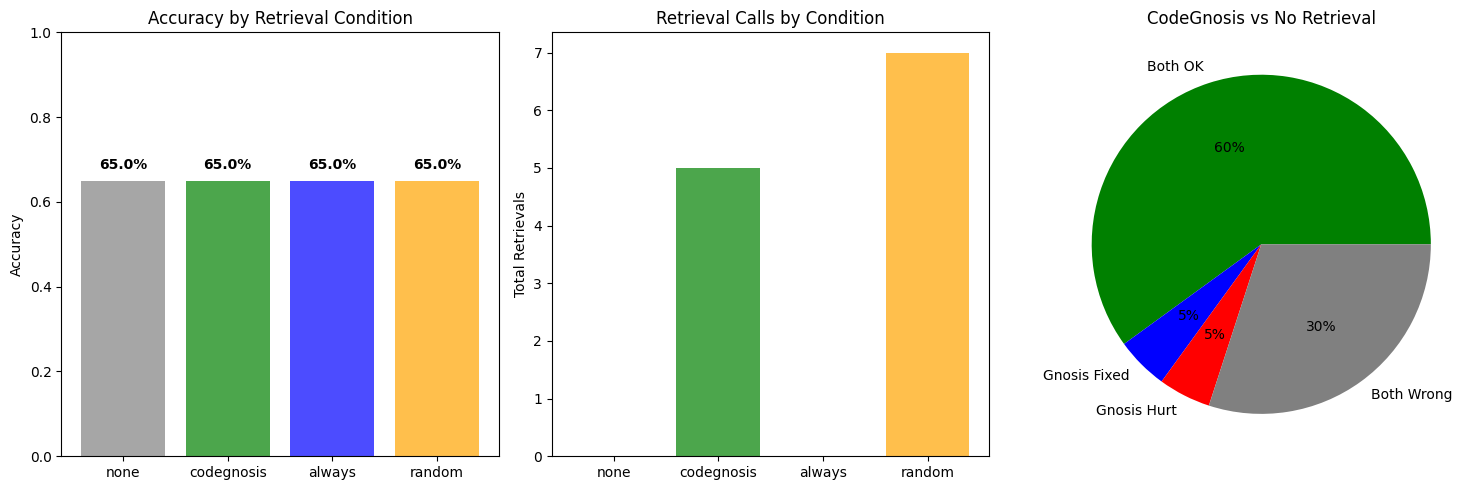

In [19]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Accuracy by condition
ax1 = axes[0]
conditions = df_summary['Condition'].tolist()
accuracies = df_summary['Accuracy'].tolist()
colors = ['gray', 'green', 'blue', 'orange']
bars = ax1.bar(conditions, accuracies, color=colors, alpha=0.7)
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy by Retrieval Condition')
ax1.set_ylim(0, 1)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.1%}', ha='center', va='bottom', fontweight='bold')

# 2. Retrieval count
ax2 = axes[1]
retrievals = df_summary['Retrievals'].tolist()
ax2.bar(conditions, retrievals, color=colors, alpha=0.7)
ax2.set_ylabel('Total Retrievals')
ax2.set_title('Retrieval Calls by Condition')

# 3. Per-task comparison
ax3 = axes[2]
comparison_data = [both_correct, gnosis_wins, gnosis_loses, both_wrong]
comparison_labels = ['Both OK', 'Gnosis Fixed', 'Gnosis Hurt', 'Both Wrong']
comparison_colors = ['green', 'blue', 'red', 'gray']
ax3.pie(comparison_data, labels=comparison_labels, colors=comparison_colors, autopct='%1.0f%%')
ax3.set_title('CodeGnosis vs No Retrieval')

plt.tight_layout()
plt.savefig('week15_codegnosis_retrieval_results.png', dpi=150)
plt.show()

In [20]:
# Final conclusion
print("="*70)
print("FINAL CONCLUSION")
print("="*70)

none_acc = sum(none_correct) / len(none_correct)
gnosis_acc = sum(gnosis_correct) / len(gnosis_correct)
always_acc = sum(always_correct) / len(always_correct)
random_acc = sum(random_correct) / len(random_correct)

gnosis_retrievals = sum(r['retrieval_count'] for r in all_results['codegnosis'])
always_retrievals = len(EVAL_TASKS)  # Always retrieves once per task

print(f"""
ACCURACY:
  No Retrieval:              {none_acc:.1%}
  CodeGnosis-triggered:      {gnosis_acc:.1%}  ({gnosis_acc - none_acc:+.1%} vs baseline)
  Always Retrieve:           {always_acc:.1%}  ({always_acc - none_acc:+.1%} vs baseline)
  Random Retrieval:          {random_acc:.1%}  ({random_acc - none_acc:+.1%} vs baseline)

EFFICIENCY:
  CodeGnosis retrievals:     {gnosis_retrievals}
  Always retrievals:         {always_retrievals}
  Retrieval savings:         {always_retrievals - gnosis_retrievals} ({100*(always_retrievals - gnosis_retrievals)/always_retrievals:.0f}% fewer)

HYPOTHESIS EVALUATION:
"The model can predict its own errors AND retrieval at those moments improves accuracy."
""")

# Evaluate hypothesis
if gnosis_acc > none_acc and gnosis_wins > gnosis_loses:
    print("SUPPORTED: CodeGnosis-triggered retrieval improves accuracy!")
    if gnosis_acc >= always_acc * 0.95 and gnosis_retrievals < always_retrievals:
        print("BONUS: Achieves similar accuracy to always-retrieve with fewer calls!")
elif gnosis_acc > none_acc:
    print("PARTIALLY SUPPORTED: Retrieval helps, but not always at the right time.")
else:
    print("NOT SUPPORTED: CodeGnosis-triggered retrieval did not improve accuracy.")

FINAL CONCLUSION

ACCURACY:
  No Retrieval:              65.0%
  CodeGnosis-triggered:      65.0%  (+0.0% vs baseline)
  Always Retrieve:           65.0%  (+0.0% vs baseline)
  Random Retrieval:          65.0%  (+0.0% vs baseline)

EFFICIENCY:
  CodeGnosis retrievals:     5
  Always retrievals:         20
  Retrieval savings:         15 (75% fewer)

HYPOTHESIS EVALUATION:
"The model can predict its own errors AND retrieval at those moments improves accuracy."

NOT SUPPORTED: CodeGnosis-triggered retrieval did not improve accuracy.


In [21]:
# Save results
output = {
    'experiment': 'Week15_CodeGnosis_Retrieval',
    'num_eval_tasks': len(EVAL_TASKS),
    'error_threshold': ERROR_THRESHOLD,
    'summary': df_summary.to_dict('records'),
    'comparison': {
        'both_correct': both_correct,
        'gnosis_wins': gnosis_wins,
        'gnosis_loses': gnosis_loses,
        'both_wrong': both_wrong,
    },
    'by_condition': {
        cond: {
            'accuracy': sum(1 for r in results if r['is_correct']) / len(results),
            'retrievals': sum(r['retrieval_count'] for r in results),
        }
        for cond, results in all_results.items()
    },
}

with open('week15_codegnosis_retrieval_results.json', 'w') as f:
    json.dump(output, f, indent=2)

print("Results saved to week15_codegnosis_retrieval_results.json")

Results saved to week15_codegnosis_retrieval_results.json


## Analysis: When Does CodeGnosis Trigger Retrieval?

Examine the cases where CodeGnosis decided to retrieve.

In [22]:
print("="*70)
print("CODEGNOSIS RETRIEVAL ANALYSIS")
print("="*70)

triggered = [r for r in all_results['codegnosis'] if r['retrieval_count'] > 0]
not_triggered = [r for r in all_results['codegnosis'] if r['retrieval_count'] == 0]

print(f"\nRetrieval triggered: {len(triggered)}/{len(all_results['codegnosis'])} tasks")

if triggered:
    triggered_correct = sum(1 for r in triggered if r['is_correct'])
    print(f"When triggered: {triggered_correct}/{len(triggered)} correct ({100*triggered_correct/len(triggered):.0f}%)")

if not_triggered:
    not_triggered_correct = sum(1 for r in not_triggered if r['is_correct'])
    print(f"When NOT triggered: {not_triggered_correct}/{len(not_triggered)} correct ({100*not_triggered_correct/len(not_triggered):.0f}%)")

# Compare to no-retrieval baseline for same tasks
print("\nDetailed breakdown:")
for i, (gnosis_r, none_r) in enumerate(zip(all_results['codegnosis'], all_results['none'])):
    if gnosis_r['retrieval_count'] > 0:
        gnosis_status = "OK" if gnosis_r['is_correct'] else "ERR"
        none_status = "OK" if none_r['is_correct'] else "ERR"
        improvement = "FIXED" if gnosis_r['is_correct'] and not none_r['is_correct'] else \
                      "HURT" if not gnosis_r['is_correct'] and none_r['is_correct'] else \
                      "SAME"
        print(f"  {gnosis_r['task'][:50]}...")
        print(f"    No retrieval: {none_status}, CodeGnosis: {gnosis_status} -> {improvement}")

CODEGNOSIS RETRIEVAL ANALYSIS

Retrieval triggered: 5/20 tasks
When triggered: 1/5 correct (20%)
When NOT triggered: 12/15 correct (80%)

Detailed breakdown:
  Write code using httpx to POST form data to a URL...
    No retrieval: OK, CodeGnosis: ERR -> HURT
  Write code using httpx to make request with cookie...
    No retrieval: ERR, CodeGnosis: ERR -> SAME
  Write code using httpx to implement retry logic wi...
    No retrieval: ERR, CodeGnosis: OK -> FIXED
  Write code using httpx to upload multipart file...
    No retrieval: ERR, CodeGnosis: ERR -> SAME
  Write code using httpx event_hooks to log request ...
    No retrieval: ERR, CodeGnosis: ERR -> SAME
